<a href="https://colab.research.google.com/github/nattapongbam/Models-for-Tuberculosis/blob/main/Adaboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -U imbalanced-learn

In [ ]:
from imblearn.ensemble import EasyEnsembleClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

In [ ]:
X_train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/classify วัณโรค /binary/binary_en/X_train_Bi31.csv')#.drop(columns=['Unnamed: 0'])
y_train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/classify วัณโรค /binary/binary_en/y_train_Bi31.csv')#.drop(columns=['Unnamed: 0'])

X_test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/classify วัณโรค /binary/binary_en/X_test_Bi30.csv')#.drop(columns=['Unnamed: 0'])
y_test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/classify วัณโรค /binary/binary_en/y_test_Bi30.csv')#.drop(columns=['Unnamed: 0'])

In [ ]:
X_train.drop(columns='period_treatment', inplace=True)
X_test.drop(columns='period_treatment', inplace=True)

In [ ]:
y_train.value_counts()

,count
0,
1,4500
0,2563


In [ ]:
y_test.value_counts()

,count
0,
1,1811
0,636


# EasyEnsamble

In [ ]:
model = EasyEnsembleClassifier(n_estimators=10, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_bagging.py:878: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


--- Confusion Matrix ---
[[ 372  264]
 [ 489 1322]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.43      0.58      0.50       636
           1       0.83      0.73      0.78      1811

    accuracy                           0.69      2447
   macro avg       0.63      0.66      0.64      2447
weighted avg       0.73      0.69      0.71      2447



# Adaboost

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.metrics import classification_report, accuracy_score

custom_weights = {0: 1.1, 1: 1}

base_model = DecisionTreeClassifier(max_depth=5, class_weight=custom_weights)

model = AdaBoostClassifier(
    estimator=base_model,
    n_estimators=1200,       # จำนวนรอบในการเรียนรู้ (จำนวน Tree)
    learning_rate=0.01,     # อัตราการเรียนรู้ (การปรับน้ำหนักในแต่ละรอบ)
    random_state=42,
)

# 4. เทรนโมเดล
model.fit(X_train, y_train)



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight={0: 1.1, 1: 1},
                                                    max_depth=5),
                   learning_rate=0.01, n_estimators=1200, random_state=42)

Accuracy Score: 0.7466

--- Classification Report ---
              precision    recall  f1-score   support

           0     0.5146    0.4434    0.4764       636
           1     0.8136    0.8531    0.8329      1811

    accuracy                         0.7466      2447
   macro avg     0.6641    0.6483    0.6546      2447
weighted avg     0.7359    0.7466    0.7402      2447



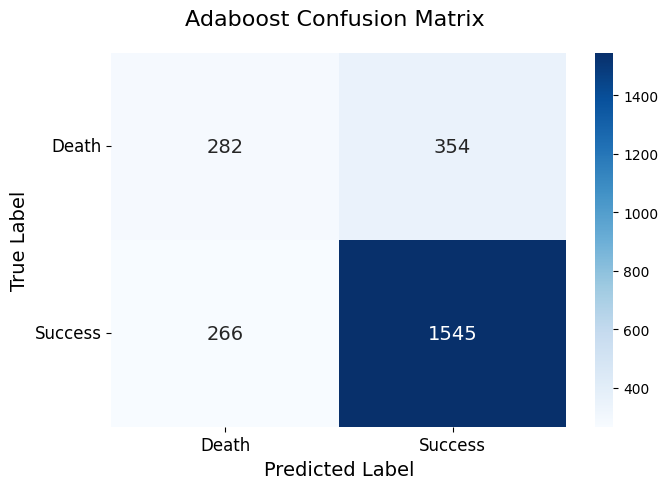

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report, f1_score

# 5. ทำนายผลและประเมิน
y_pred = model.predict(X_test)

print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, digits=4))

my_labels = ['Death', 'Success']
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                 xticklabels=my_labels,
                 yticklabels=my_labels,
                 annot_kws={"size": 14}) # ขนาดตัวอักษรของตัวเลขข้างในกล่อง

# 4. ตกแต่งหัวข้อและแกนให้ชัดเจน
plt.title('Adaboost Confusion Matrix ', fontsize=16, pad=20)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)

# 5. ปรับขนาดฟอนต์ของชื่อคลาส (Death, Fail, Success)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)

# 6. แสดงผลกราฟ
plt.tight_layout()
plt.show()

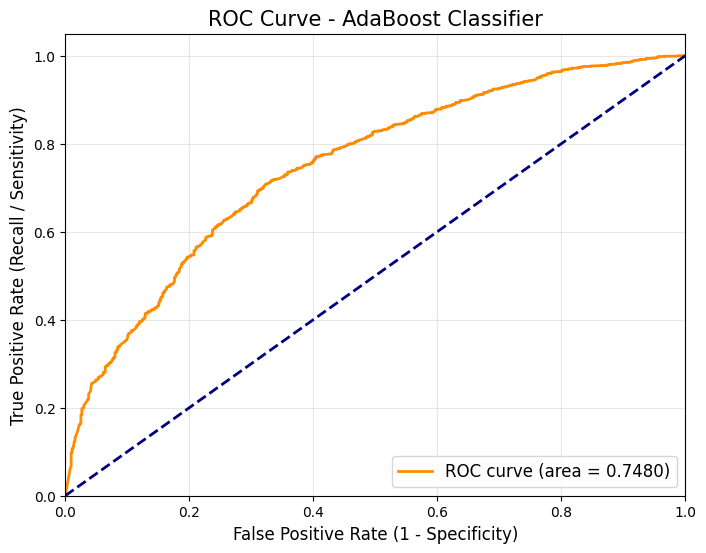

ค่า AUC Score ของ AdaBoost คือ: 0.7480


In [ ]:
from sklearn.metrics import roc_curve, auc

# 1. คำนวณความน่าจะเป็น (Probability) ของคลาส Success (คลาส 1)
# predict_proba จะคืนค่า [prob_death, prob_success] เราจึงเลือกคอลัมน์ index 1
y_score = model.predict_proba(X_test)[:, 1]

# 2. คำนวณค่า FPR, TPR และ AUC
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# 3. พล็อตกราฟ
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')

# ลากเส้นประสีน้ำเงินแสดงการสุ่ม (Baseline)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# ตกแต่งกราฟ
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=12)
plt.title('ROC Curve - AdaBoost Classifier', fontsize=15)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)

plt.show()

print(f"ค่า AUC Score ของ AdaBoost คือ: {roc_auc:.4f}")

ตรวจ overfit

In [ ]:
# 1. ทำนายผลทั้งสองชุด
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 2. พิมพ์ผลเปรียบเทียบ
print("=== Performance Comparison ===")
print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")

print("\n--- Training Report ---")
print(classification_report(y_train, y_train_pred, digits=4))

print("\n--- Test Report ---")
print(classification_report(y_test, y_test_pred, digits=4))

=== Performance Comparison ===
Train Accuracy: 0.7335
Test Accuracy:  0.7466

--- Training Report ---
              precision    recall  f1-score   support

           0     0.6801    0.5018    0.5775      2563
           1     0.7531    0.8656    0.8054      4500

    accuracy                         0.7335      7063
   macro avg     0.7166    0.6837    0.6914      7063
weighted avg     0.7266    0.7335    0.7227      7063


--- Test Report ---
              precision    recall  f1-score   support

           0     0.5146    0.4434    0.4764       636
           1     0.8136    0.8531    0.8329      1811

    accuracy                         0.7466      2447
   macro avg     0.6641    0.6483    0.6546      2447
weighted avg     0.7359    0.7466    0.7402      2447



--- Starting 5-Fold Cross-Validation ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Fold 1: Accuracy = 0.7028, F1-Score = 0.6887


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Fold 2: Accuracy = 0.7070, F1-Score = 0.6886


...

Fold 4: Accuracy = 0.7082, F1-Score = 0.6906


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Fold 5: Accuracy = 0.7330, F1-Score = 0.7251
------------------------------
Average K-Fold Accuracy: 0.7079 (+/- 0.0144)
Average K-Fold F1-Score: 0.6927
------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



--- Final Classification Report (on Test Set) ---
              precision    recall  f1-score   support

           0     0.5146    0.4434    0.4764       636
           1     0.8136    0.8531    0.8329      1811

    accuracy                         0.7466      2447
   macro avg     0.6641    0.6483    0.6546      2447
weighted avg     0.7359    0.7466    0.7402      2447



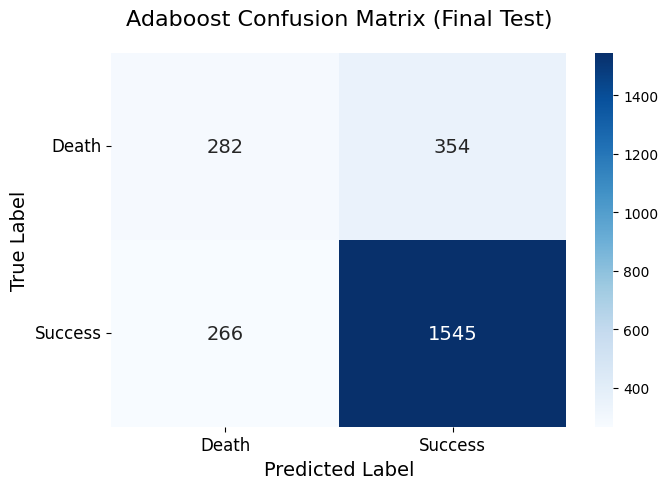

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score

# 1. ตั้งค่า Model และ Weights
custom_weights = {0: 1.1, 1: 1}
base_model = DecisionTreeClassifier(max_depth=5, class_weight=custom_weights)

model = AdaBoostClassifier(
    estimator=base_model,
    n_estimators=1200,
    learning_rate=0.01,
    random_state=42,
)

# 2. การทำ Stratified K-fold (บน X_train เท่านั้น)
# ใช้ 5-fold เพื่อดูความเสถียร
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
fold_f1_scores = []

print(f"--- Starting 5-Fold Cross-Validation ---")

for i, (train_index, val_index) in enumerate(skf.split(X_train, y_train)):
    # แบ่งข้อมูลในแต่ละ Fold
    X_fold_train, X_fold_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_fold_train, y_fold_val = y_train.iloc[train_index], y_train.iloc[val_index]

    # เทรนโมเดลด้วยข้อมูลใน Fold นั้นๆ
    model.fit(X_fold_train, y_fold_train)

    # ทำนายผลบน Validation Fold
    y_val_pred = model.predict(X_fold_val)

    # เก็บค่าคะแนน
    acc = accuracy_score(y_fold_val, y_val_pred)
    f1 = f1_score(y_fold_val, y_val_pred, average='weighted')

    fold_accuracies.append(acc)
    fold_f1_scores.append(f1)

    print(f"Fold {i+1}: Accuracy = {acc:.4f}, F1-Score = {f1:.4f}")

print("-" * 30)
print(f"Average K-Fold Accuracy: {np.mean(fold_accuracies):.4f} (+/- {np.std(fold_accuracies):.4f})")
print(f"Average K-Fold F1-Score: {np.mean(fold_f1_scores):.4f}")
print("-" * 30)

# 3. เทรนโมเดลด้วย X_train ทั้งหมดอีกครั้ง เพื่อทดสอบกับ X_test (Final Evaluation)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 4. แสดงผลลัพธ์สุดท้าย
print("\n--- Final Classification Report (on Test Set) ---")
print(classification_report(y_test, y_pred, digits=4))

# 5. วาด Confusion Matrix
my_labels = ['Death', 'Success']
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                 xticklabels=my_labels,
                 yticklabels=my_labels,
                 annot_kws={"size": 14})

plt.title('Adaboost Confusion Matrix (Final Test)', fontsize=16, pad=20)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()

--- Top 10 Feature Importances ---
          Feature  Importance
1             age    0.392777
0          weight    0.155770
10  pos_disease_0    0.106897
14          HIV_2    0.081228
13          HIV_1    0.076208
18             LD    0.037668
12          HIV_0    0.019731
5        ICD_10_1    0.019065
15            CKD    0.016930
6        ICD_10_2    0.016346


/tmp/ipykernel_2056/3765300852.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='magma')


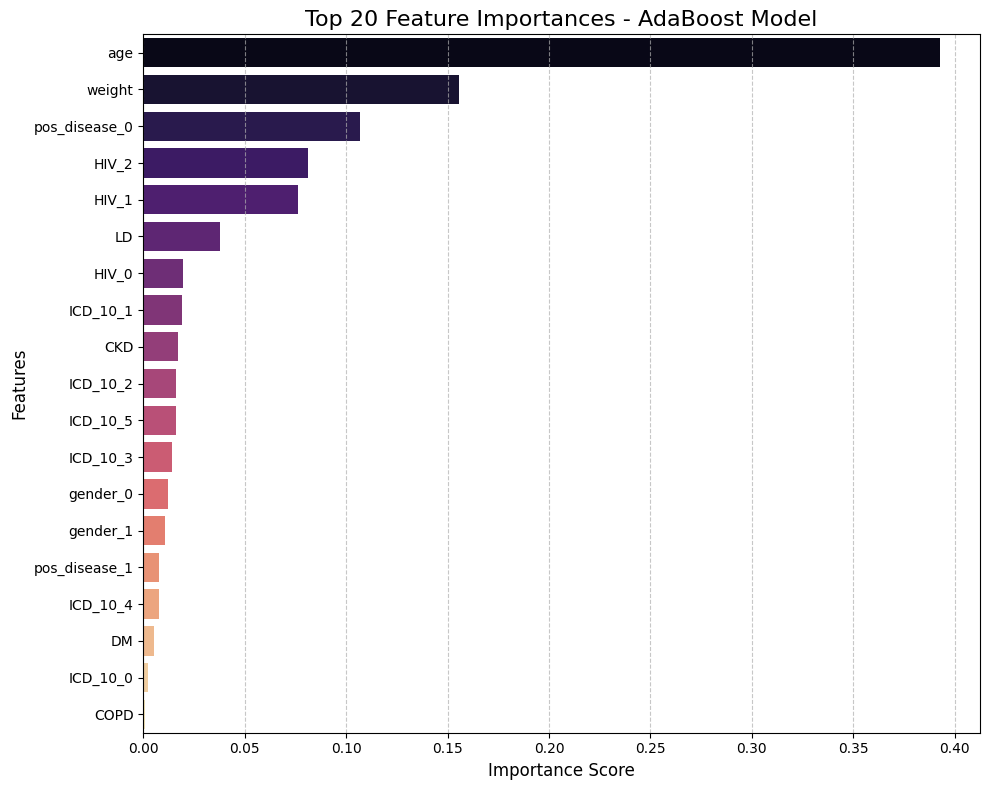

In [ ]:
import pandas as pd

# 1. ดึงค่าความสำคัญของ Feature ออกมา
importances = model.feature_importances_
feature_names = X_train.columns

# 2. สร้าง DataFrame เพื่อจัดกลุ่มและเรียงลำดับ
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. แสดง 10 อันดับแรกในรูปแบบข้อความ
print("--- Top 10 Feature Importances ---")
print(feature_importance_df.head(10))

# 4. วาดกราฟเพื่อให้ดูง่ายขึ้น
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='magma')

plt.title('Top 20 Feature Importances - AdaBoost Model', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()